# Análisis de Violencia INE

Cuaderno de análisis sobre la base **Base_Violencia_INE_Unificada_LIMPIA.csv**.

In [23]:
# Verificación e instalación de dependencias requeridas
import importlib.util
import subprocess
import sys

required_packages = {
    "pandas": "pandas",
    "numpy": "numpy",
    "matplotlib": "matplotlib",
    "seaborn": "seaborn",
    "scipy": "scipy",
    "scikit-learn": "sklearn",
    "pyarrow": "pyarrow",
}

missing = [
    pip_name
    for pip_name, module_name in required_packages.items()
    if importlib.util.find_spec(module_name) is None
]

if missing:
    print("Instalando paquetes faltantes:", ", ".join(missing))
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing])
    print("Instalación completada.")
else:
    print("Todas las dependencias ya están instaladas.")

Todas las dependencias ya están instaladas.


## 1. Fundamentación

In [24]:
# 1) Importaciones y configuración
import os
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 160)

In [ ]:
# 2) Definición de rutas de la base de datos
candidate_paths = [
    Path("Base_Violencia_INE_Unificada_LIMPIA.csv")
]

DATA_PATH = None
for p in candidate_paths:
    if p.exists():
        DATA_PATH = p
        break

if DATA_PATH is None:
    raise FileNotFoundError(
        "No se encontró Base_Violencia_INE_Unificada_LIMPIA.csv en rutas esperadas."
    )

print(f"Archivo de entrada: {DATA_PATH.resolve()}")

Archivo de entrada: C:\Users\jmo\Documents\MineriaDeDatos\ProyectoMineria\Base_Violencia_INE_Unificada_LIMPIA.csv


## 2. Depuración y Estandarización de Datos

In [26]:
def limpiar_datos(filepath):
    print("Cargando datos...")
    df = pd.read_csv(filepath, low_memory=False)

    # Eliminar columnas completamente vacías
    df.dropna(how="all", axis=1, inplace=True)

    # Selección de variables numéricas relevantes por patrón
    patron = re.compile(r"otr[oa]s|victimas|agresores|hijos|hij", flags=re.IGNORECASE)
    cols_numericas = [col for col in df.columns if patron.search(col)]
    if "agr_edad" in df.columns and "agr_edad" not in cols_numericas:
        cols_numericas.append("agr_edad")

    print("Transformando y limpiando variables numéricas...")
    for col in cols_numericas:
        df[col] = df[col].astype(str)
        df[col] = df[col].str.replace("98 y más", "98", regex=False)
        df[col] = df[col].str.replace(r"(?i)ningun[oa]", "0", regex=True)
        df[col] = df[col].replace(["Ignorado", "No indica", "NA", "nan", "<NA>"], np.nan)
        df[col] = pd.to_numeric(df[col], errors="coerce")

    print("Formateando fechas...")
    if "fecha_hecho_limpia" in df.columns:
        df["fecha_hecho_limpia"] = pd.to_datetime(df["fecha_hecho_limpia"], errors="coerce")
        df = df.dropna(subset=["fecha_hecho_limpia"])

    print("Limpieza finalizada.")
    return df

In [27]:
df = limpiar_datos(DATA_PATH)
print("Dimensiones del dataset limpio:", df.shape)
df.head()

Cargando datos...
Transformando y limpiando variables numéricas...
Formateando fechas...
Limpieza finalizada.
Dimensiones del dataset limpio: (515946, 70)


,anio_registro,fecha_hecho_limpia,departamento_limpio,sexo_limpio,edad_limpia,etnia_limpia,quien_reporta,total_hijos,num_hij_hom,num_hij_muj,vic_alfab,vic_escolaridad,vic_est_civ,vic_nacional,vic_trabaja,vic_ocup,vic_dedica,vic_disc,tipo_discaq,vic_rel_agr,otras_victimas,vic_otras_hom,vic_otras_muj,vic_otras_n_os,vic_otras_n_as,hec_area,hec_tipagre,hec_recur_denun,inst_donde_denuncio,agr_sexo,agr_edad,agr_alfab,agr_escolaridad,agr_est_civ,agr_gurpet,agr_nacional,agr_trabaja,agr_ocup,agr_dedica,inst_denun_hecho,medidas_seguridad,agr_grupet,ley_aplicable,agresores_otros_total,agr_otros_hom,agr_otras_muj,agr_otros_n_os,agr_otras_n_as,tipo_medida,organismo_jurisdiccional,conducente,articulovif1,articulovif2,articulovif3,articulovif4,articulovcm1,articulovcm2,articulovcm3,articulovcm4,articulocodpen1,articulocodpen2,articulocodpen3,articulocodpen4,articulotras1,articulotras2,articulotras3,articulotras4,organismo_remite,filter,numero_boleta
0,2008,2008-01-04,Villa Nueva,Mujer,21.0,Ladinos(as),Víctima,2.0,2.0,0.0,Alfabeta,Tercero primaria,Unidos(as),Guatemalteca,Si trabaja por un salario o ingreso,Vendedores ambulantes de productos no comestibles,NaN,Con discapacidad,Ignorado,Conviviente,2.0,0.0,0.0,2.0,0.0,Urbana,Física-psicológica,No,NaN,Hombres,25.0,Alfabeta,Sexto primaria,Unidos(as),Ladinos(as),Guatemalteca,Si trabaja por un salario o ingreso,Vendedores ambulantes de productos comestibles,NaN,Organismo Judicial,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2008,2007-12-02,Guatemala,Mujer,43.0,No indica,Víctima,3.0,2.0,1.0,Alfabeta,Segundo primaria,Casados(as),Guatemalteca,Si trabaja por un salario o ingreso,Personal domestico,NaN,Sin discapacidad,NaN,Esposos(a),3.0,2.0,1.0,0.0,0.0,Urbana,Física-psicológica-patrimonial,No,NaN,Hombres,NaN,Alfabeta,Básico grado ignorado,Casados(as),No indica,Guatemalteca,Si trabaja por un salario o ingreso,Persona de partería y enfermería,NaN,Procuraduría de los Derechos Humanos,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2008,2008-01-06,Guatemala,Mujer,43.0,Ladinos(as),Víctima,2.0,1.0,1.0,Alfabeta,Primaria grado ignorado,Solteros(as),Guatemalteca,Si trabaja por un salario o ingreso,Niñeras y celadoras infantiles,NaN,Sin discapacidad,NaN,Ex-cónyuges,2.0,0.0,0.0,1.0,1.0,Urbana,Psicológica-patrimonial,Si,Ministerio Público,Hombres,41.0,Alfabeta,Primaria grado ignorado,Solteros(as),Ladinos(as),Guatemalteca,Si trabaja por un salario o ingreso,"Panaderos, pasteleros y confiteros",NaN,Procuraduría de los Derechos Humanos,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2008,2008-01-08,Guatemala,Mujer,35.0,Ladinos(as),Víctima,3.0,2.0,1.0,Alfabeta,Básico grado ignorado,Casados(as),Guatemalteca,No trabaja por un salario o ingreso,NaN,Quehaceres del hogar,Con discapacidad,Ignorado,Esposos(a),3.0,0.0,0.0,2.0,1.0,Ignorado,Física-psicológica,No,NaN,Hombres,35.0,Alfabeta,Primaria grado ignorado,Casados(as),Ladinos(as),Guatemalteca,No trabaja por un salario o ingreso,NaN,Desempleado,Procuraduría de los Derechos Humanos,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2008,2008-01-07,Guatemala,Mujer,26.0,Ladinos(as),Víctima,3.0,1.0,2.0,Alfabeta,Primaria grado ignorado,Casados(as),Guatemalteca,No trabaja por un salario o ingreso,NaN,Quehaceres del hogar,Sin discapacidad,NaN,Esposos(a),NaN,NaN,NaN,NaN,NaN,Ignorado,Física-psicológica,No,NaN,Hombres,27.0,Alfabeta,Primaria grado ignorado,Casados(as),Ignorado,Guatemalteca,Si trabaja por un salario o ingreso,Vendedores ambulantes de productos no comestibles,NaN,Procuraduría de los Derechos Humanos,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Exploración Descriptiva

In [28]:
def generar_exploracion(df):
    cols_num = df.select_dtypes(include=[np.number]).columns
    cols_num = [c for c in cols_num if not re.search(r"boleta|id|codigo", c, re.IGNORECASE)]

    if not cols_num:
        raise ValueError("No se identificaron variables numéricas para exploración.")

    df_num = df[cols_num]

    resumen = df_num.describe().T
    resumen_reducido = resumen[["mean", "50%", "std", "min", "25%", "75%", "max"]]
    print("--- TABLA RESUMEN DE VARIABLES NUMÉRICAS ---")
    display(resumen_reducido)

    print("Generando histogramas de distribución...")
    num_cols_count = len(cols_num)
    filas = (num_cols_count + 3) // 4
    fig = plt.figure(figsize=(16, 4 * filas))

    for i, col in enumerate(cols_num, 1):
        ax = fig.add_subplot(filas, 4, i)
        sns.histplot(df_num[col].dropna(), bins=30, color="#2A9D8F", edgecolor="white", alpha=0.8, ax=ax)
        ax.set_title(col, fontweight="bold", fontsize=10)
        ax.set_ylabel("Frecuencia")
        ax.set_xlabel("")
        ax.tick_params(axis="x", rotation=45)

    plt.suptitle("Distribución de Variables Numéricas\nAnálisis de Frecuencias (INE)", y=1.02, fontsize=14)
    plt.tight_layout()
    plt.show()

    return resumen_reducido

--- TABLA RESUMEN DE VARIABLES NUMÉRICAS ---


,mean,50%,std,min,25%,75%,max
anio_registro,2015.699089,2016.0,4.599212,2008.0,2012.0,2020.0,2023.0
edad_limpia,33.185608,30.0,12.837470,1.0,24.0,39.0,97.0
total_hijos,2.163254,2.0,1.784004,0.0,1.0,3.0,19.0
num_hij_hom,1.116504,1.0,1.150512,0.0,0.0,2.0,15.0
num_hij_muj,1.046705,1.0,1.131448,0.0,0.0,2.0,14.0
otras_victimas,1.008635,0.0,1.492836,0.0,0.0,2.0,20.0
vic_otras_hom,32.544481,0.0,46.434609,0.0,0.0,99.0,99.0
vic_otras_muj,32.583605,0.0,46.407868,0.0,0.0,99.0,99.0
vic_otras_n_os,32.737307,0.0,46.302995,0.0,0.0,99.0,99.0
vic_otras_n_as,32.718688,0.0,46.315666,0.0,0.0,99.0,99.0


Generando histogramas de distribución...


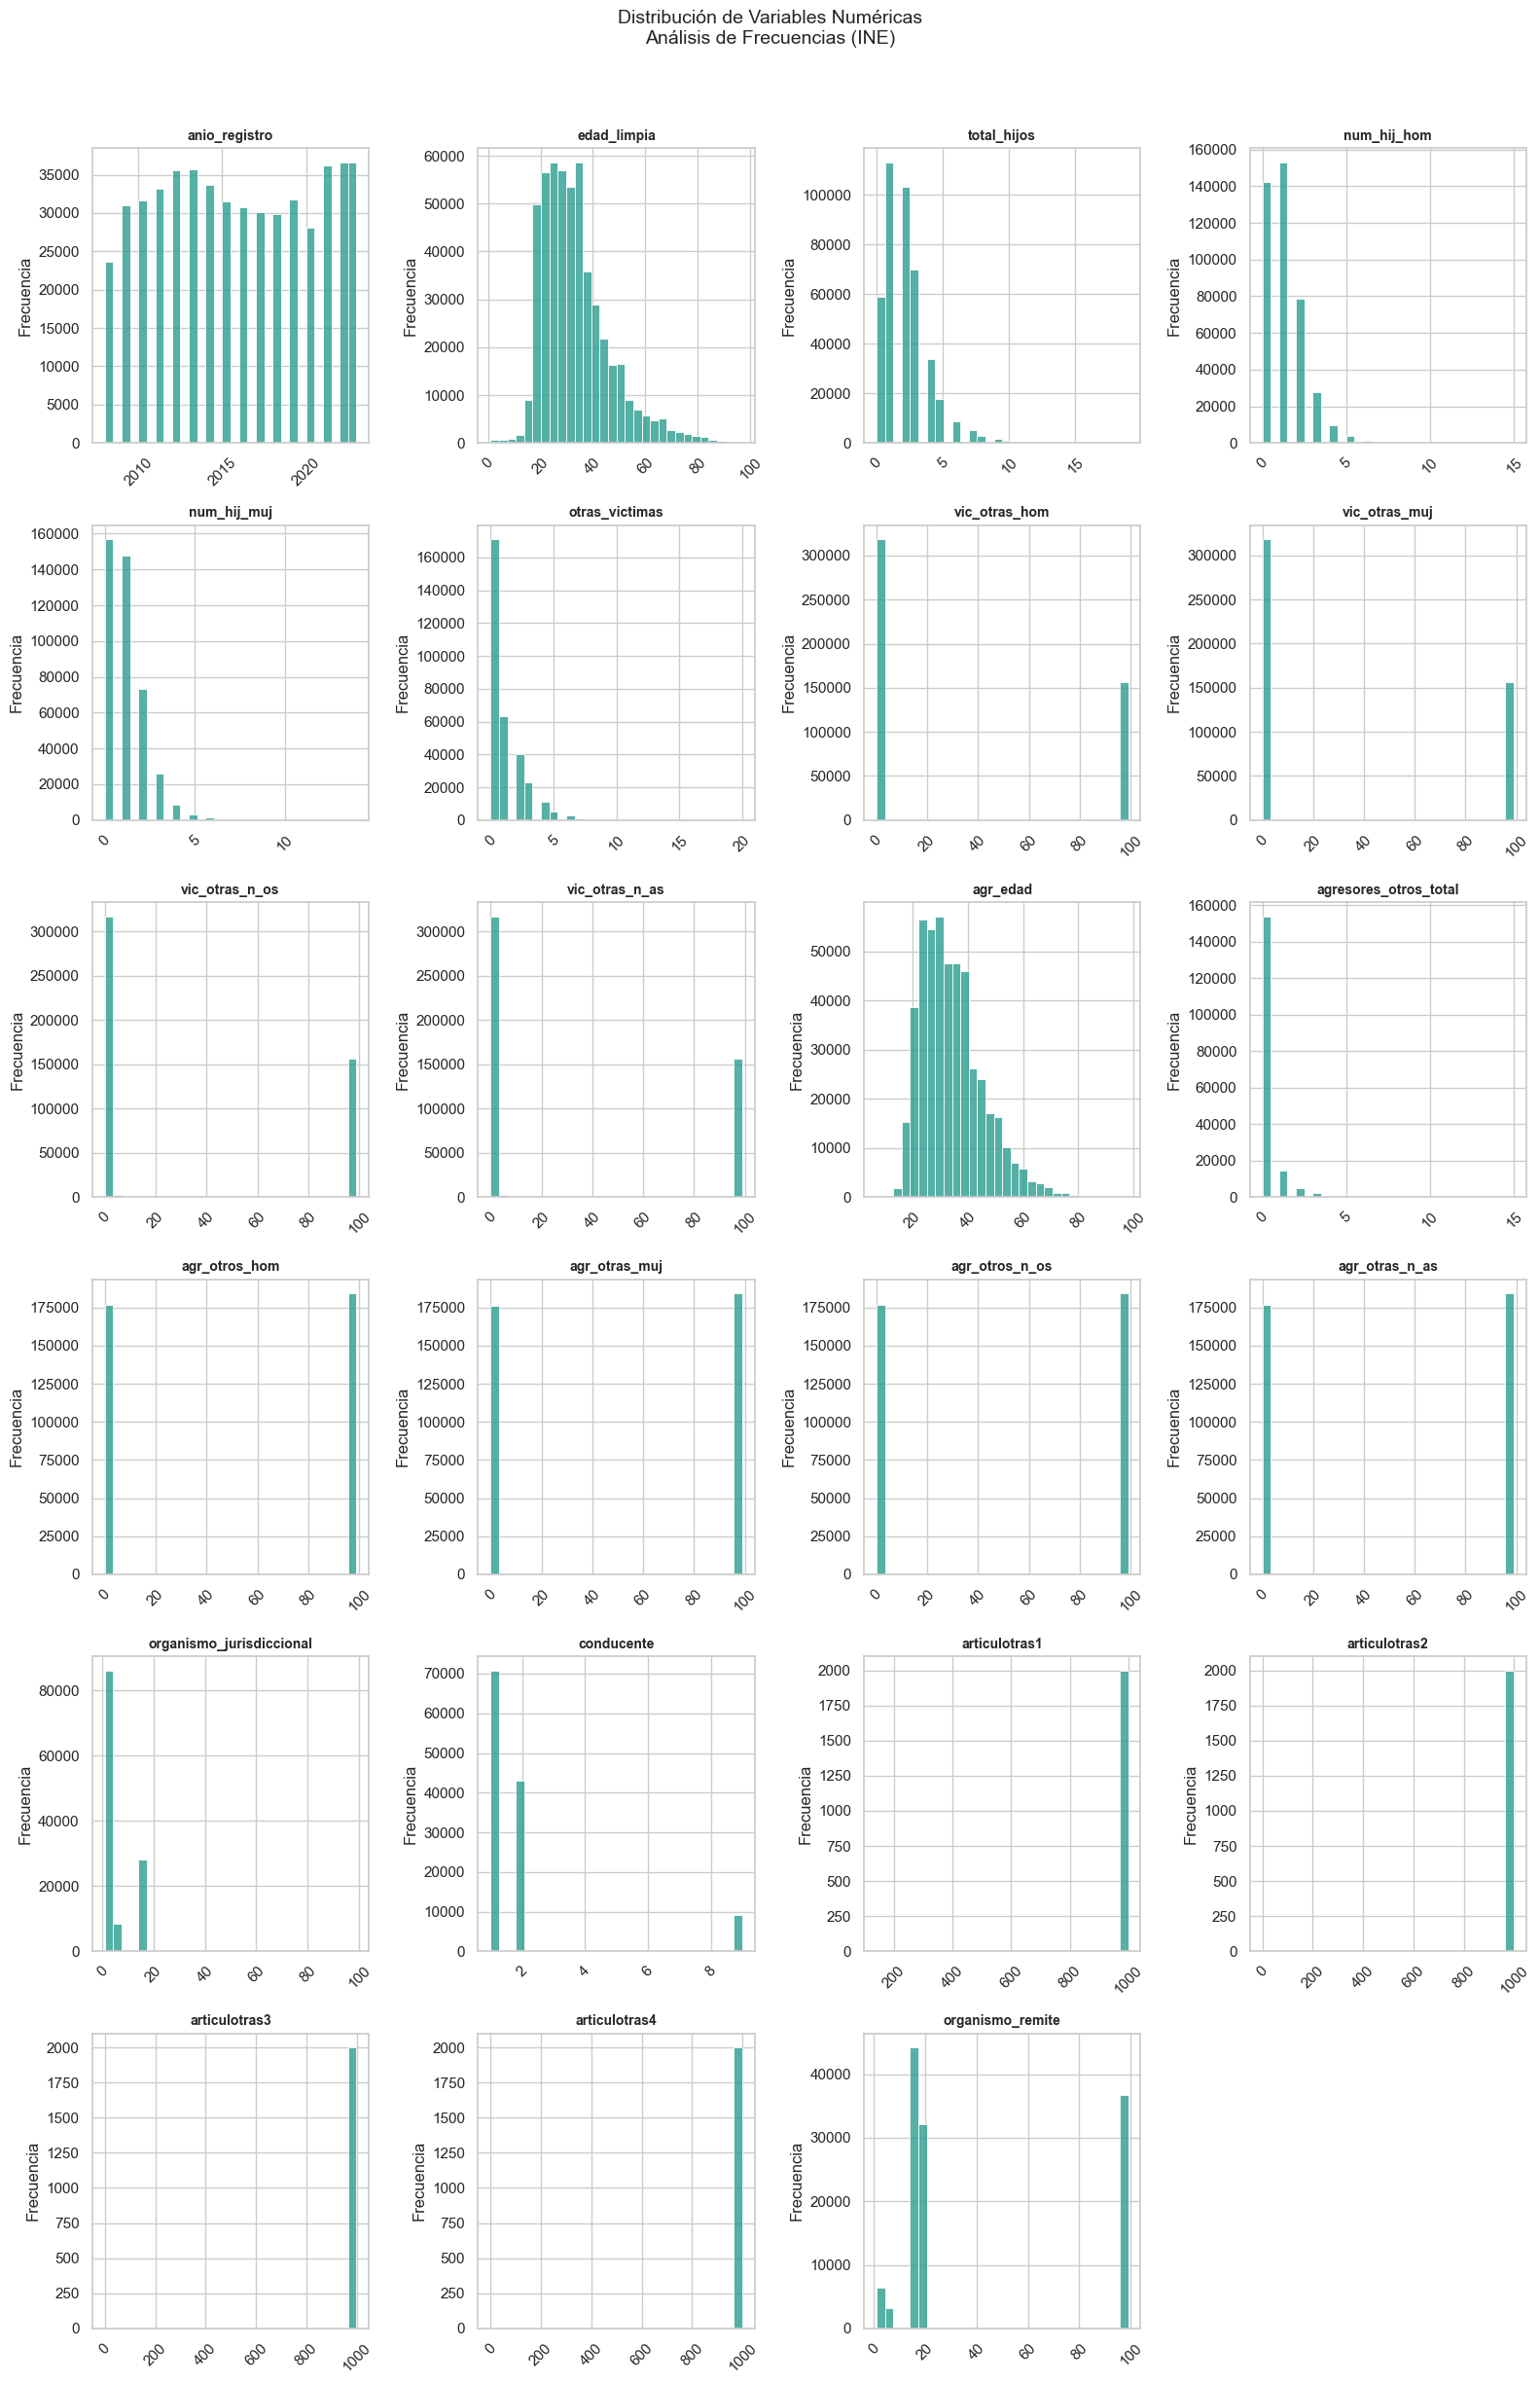

Resumen estadístico generado y mostrado en el cuaderno.


In [29]:
resumen_estadistico = generar_exploracion(df)
print("Resumen estadístico generado y mostrado en el cuaderno.")

## 4. Evaluación Preliminar de Normalidad

In [30]:
def prueba_normalidad(df):
    print("Generando Q-Q Plots...")
    df_muestra = df.sample(n=min(5000, len(df)), random_state=123)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    if "edad_limpia" in df_muestra.columns:
        stats.probplot(df_muestra["edad_limpia"].dropna(), dist="norm", plot=axes[0])
        axes[0].set_title("Q-Q Plot: Edad Víctima")
        axes[0].get_lines()[1].set_color("red")
    else:
        axes[0].set_title("edad_limpia no disponible")
        axes[0].text(0.5, 0.5, "Columna ausente", ha="center", va="center")

    if "total_hijos" in df_muestra.columns:
        stats.probplot(df_muestra["total_hijos"].dropna(), dist="norm", plot=axes[1])
        axes[1].set_title("Q-Q Plot: Total Hijos")
        axes[1].get_lines()[1].set_color("red")
    else:
        axes[1].set_title("total_hijos no disponible")
        axes[1].text(0.5, 0.5, "Columna ausente", ha="center", va="center")

    plt.tight_layout()
    plt.show()

Generando Q-Q Plots...


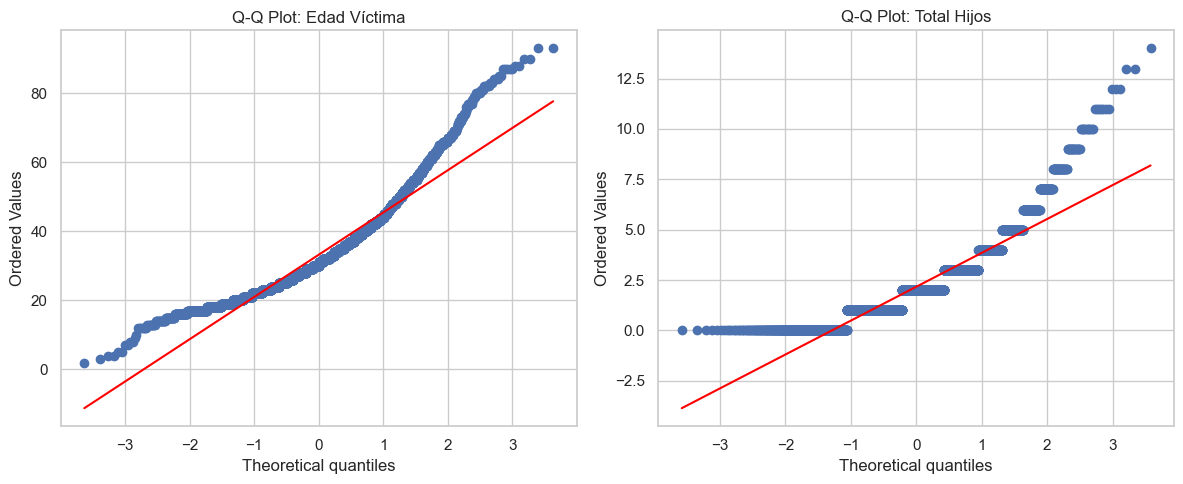

Q-Q plots generados y mostrados en el cuaderno.


In [31]:
prueba_normalidad(df)
print("Q-Q plots generados y mostrados en el cuaderno.")

## 5. Modelado No Supervisado: Clustering K-Means

In [32]:
def realizar_clustering(df):
    print("Preparando variables para clustering...")
    features = ["edad_limpia", "total_hijos"]

    faltantes = [f for f in features if f not in df.columns]
    if faltantes:
        raise ValueError(f"No se encontraron columnas requeridas para clustering: {faltantes}")

    df_cluster = df[features].dropna().copy()

    scaler = StandardScaler()
    df_scaled = scaler.fit_transform(df_cluster)

    print("Ejecutando K-Means (k=3)...")
    kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
    df_cluster["Cluster"] = kmeans.fit_predict(df_scaled)

    centroides = pd.DataFrame(scaler.inverse_transform(kmeans.cluster_centers_), columns=features)
    centroides.index.name = "Cluster"

    print("\nCentroides de los clústeres resultantes:")
    display(centroides)

    plt.figure(figsize=(8, 6))
    sns.scatterplot(
        x="edad_limpia",
        y="total_hijos",
        hue="Cluster",
        data=df_cluster,
        palette="viridis",
        alpha=0.5
    )
    plt.title("Segmentación de Perfiles de Víctimas (K-Means, k=3)")
    plt.tight_layout()
    plt.show()

    return df_cluster, centroides

Preparando variables para clustering...
Ejecutando K-Means (k=3)...

Centroides de los clústeres resultantes:


,edad_limpia,total_hijos
Cluster,,
0,26.372007,1.419679
1,40.490611,4.767327
2,51.868189,1.824003


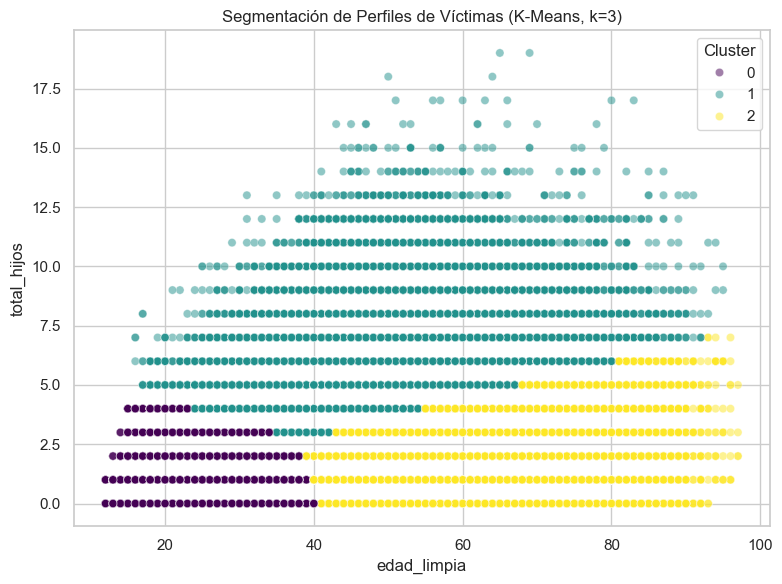

Clustering ejecutado y resultados mostrados en el cuaderno.


In [33]:
df_cluster, centroides = realizar_clustering(df)
print("Clustering ejecutado y resultados mostrados en el cuaderno.")

## 6. Síntesis de Resultados

En las celdas de código anteriores, se unificó el proceso completo de análisis:
- Carga y limpieza desde el archivo CSV principal.
- Exploración estadística y visualización de distribuciones.
- Evaluación de normalidad para variables clave.
- Segmentación con K-Means y visualización de centroides y clústeres dentro del cuaderno.

## 7. Preparación de Datos para Modelado Supervisado

En este apartado se construye una variable respuesta binaria para estimar riesgo de violencia física y se prepara una matriz de predictores para modelos de clasificación.

### Paso 1. Transformación de la Variable Respuesta (Binarización)

Criterio aplicado sobre `hec_tipagre`:
- Se asigna `1` si la categoría pertenece a: Física, Física-psicológica, Física-psicológica-patrimonial.
- Se asigna `0` si la categoría pertenece a: Psicológica, Psicológica-patrimonial, Patrimonial.
- Valores nulos y categorías fuera de este conjunto (por ejemplo, Otros) se asignan como `NaN` para excluirse del entrenamiento supervisado.

In [34]:
import unicodedata

def normalizar_texto_categoria(x):
    if pd.isna(x):
        return np.nan
    txt = str(x).strip().lower()
    txt = "".join(ch for ch in unicodedata.normalize("NFKD", txt) if not unicodedata.combining(ch))
    txt = re.sub(r"\s+", " ", txt)
    return txt

categorias_riesgo_alto = {
    "fisica",
    "fisica-psicologica",
    "fisica-psicologica-patrimonial",
}

categorias_riesgo_bajo = {
    "psicologica",
    "psicologica-patrimonial",
    "patrimonial",
}

hec_norm = df["hec_tipagre"].apply(normalizar_texto_categoria)

# Valores fuera del esquema (incluye 'otros') y nulos quedan como NaN.
df["riesgo_violencia_fisica"] = np.select(
    [hec_norm.isin(categorias_riesgo_alto), hec_norm.isin(categorias_riesgo_bajo)],
    [1, 0],
    default=np.nan
)

print("Distribución de riesgo_violencia_fisica (incluye NaN):")
display(df["riesgo_violencia_fisica"].value_counts(dropna=False).rename("conteo").to_frame())

print("Ejemplos de categorías no mapeadas (incluye posibles 'otros'):")
display(
    df.loc[df["riesgo_violencia_fisica"].isna(), "hec_tipagre"]
      .value_counts(dropna=False)
      .head(10)
      .rename("conteo")
      .to_frame()
)

Distribución de riesgo_violencia_fisica (incluye NaN):


,conteo
riesgo_violencia_fisica,
1.0,270974
0.0,195411
NaN,49561


Ejemplos de categorías no mapeadas (incluye posibles 'otros'):


,conteo
hec_tipagre,
PsicolÃ³gica,18731
FÃ­sica-psicolÃ³gica,11012
Física-psicológica-sexual,4557
FÃ­sica,3643
Física-psicológica-sexual-patrimonial,2728
Psicológica-sexual,1858
Sexual,1523
Física-Patrimonial,1378
PsicolÃ³gica-patrimonial,1364


### Paso 2. Selección de Variables Predictoras (Features)

Se retienen únicamente la variable respuesta y los predictores definidos para el problema supervisado.

In [35]:
columnas_modelo = [
    "riesgo_violencia_fisica",
    "edad_limpia",
    "total_hijos",
    "agr_edad",
    "vic_rel_agr",
    "vic_trabaja",
]

df_modelo = df[columnas_modelo].copy()

# Para modelado supervisado se excluyen registros sin etiqueta binaria válida.
df_modelo = df_modelo.dropna(subset=["riesgo_violencia_fisica"]).copy()
df_modelo["riesgo_violencia_fisica"] = df_modelo["riesgo_violencia_fisica"].astype(int)

print("Dimensión del dataset para modelado:", df_modelo.shape)
display(df_modelo.head())

Dimensión del dataset para modelado: (466385, 6)


,riesgo_violencia_fisica,edad_limpia,total_hijos,agr_edad,vic_rel_agr,vic_trabaja
0,1,21.0,2.0,25.0,Conviviente,Si trabaja por un salario o ingreso
1,1,43.0,3.0,NaN,Esposos(a),Si trabaja por un salario o ingreso
2,0,43.0,2.0,41.0,Ex-cónyuges,Si trabaja por un salario o ingreso
3,1,35.0,3.0,35.0,Esposos(a),No trabaja por un salario o ingreso
4,1,26.0,3.0,27.0,Esposos(a),No trabaja por un salario o ingreso


### Paso 3 y 4. Escalamiento Numérico y Encoding Categórico

Se utiliza **MinMaxScaler** porque en el análisis exploratorio las variables numéricas no siguen normalidad; este escalador no asume distribución normal y lleva cada variable al rango [0, 1], facilitando comparabilidad para modelos lineales y basados en distancia.

In [36]:
from sklearn.preprocessing import MinMaxScaler

variables_numericas = ["edad_limpia", "total_hijos", "agr_edad"]
variables_categoricas = ["vic_rel_agr", "vic_trabaja"]

df_prep = df_modelo.copy()

# Imputación mínima para no perder filas durante el escalamiento.
for col in variables_numericas:
    mediana = df_prep[col].median()
    df_prep[col] = df_prep[col].fillna(mediana)

# Elegimos MinMaxScaler por no requerir normalidad y acotar escala a [0, 1].
scaler = MinMaxScaler()
df_prep[variables_numericas] = scaler.fit_transform(df_prep[variables_numericas])

# En categóricas, convertimos nulos a categoría explícita antes de one-hot encoding.
for col in variables_categoricas:
    df_prep[col] = df_prep[col].fillna("No_especifica").astype(str)

X = pd.get_dummies(
    df_prep[variables_numericas + variables_categoricas],
    columns=variables_categoricas,
    drop_first=True,
    dtype=int
)
y = df_prep["riesgo_violencia_fisica"]

print("Matriz de predictores X:", X.shape)
print("Vector respuesta y:", y.shape)
display(X.head())
display(y.value_counts().rename("conteo").to_frame())

Matriz de predictores X: (466385, 19)
Vector respuesta y: (466385,)


,edad_limpia,total_hijos,agr_edad,vic_rel_agr_Esposos(a),vic_rel_agr_Esposos(as),vic_rel_agr_Ex-cÃ³nyuges,vic_rel_agr_Ex-cónyuges,vic_rel_agr_Hermanos(as),vic_rel_agr_Hijastros(as),vic_rel_agr_Hijos(as),vic_rel_agr_Nietos(as),vic_rel_agr_Otro pariente,vic_rel_agr_Padres/madres,vic_rel_agr_Suegros(as),vic_trabaja_No,vic_trabaja_No trabaja por un salario o ingreso,vic_trabaja_No_especifica,vic_trabaja_Si,vic_trabaja_Si trabaja por un salario o ingreso
0,0.208333,0.105263,0.188889,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
1,0.437500,0.157895,0.266667,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
2,0.437500,0.105263,0.366667,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1
3,0.354167,0.157895,0.300000,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0
4,0.260417,0.157895,0.211111,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0


,conteo
riesgo_violencia_fisica,
1,270974
0,195411
